In [1]:
import numpy as np
import pygame
from skimage.measure import block_reduce
import matplotlib.pyplot as plt
from env_map import env
from agent import agent


pygame 2.6.1 (SDL 2.28.4, Python 3.12.4)
Hello from the pygame community. https://www.pygame.org/contribute.html


In [2]:
'''
BMP to 2D numpy
'''
fname = 'map3'
surface = pygame.image.load(f'bmps/{fname}.bmp')
arr = pygame.surfarray.array3d(surface)
arr = arr[:,:,0] # only need one col as 
                 # white will be 255 for all 3
greyscale_arr = (arr > 0 ).astype(int) #set whites=1

(16, 16)


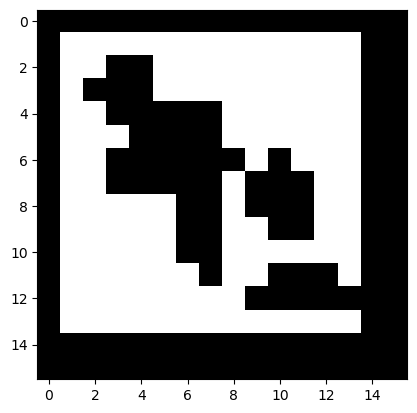

In [3]:
'''
abstract map using min pooling:

takes min value of each block, set the 
new abstracted block to that
'''
abs_siz = (40,40)
pooled_map = block_reduce(greyscale_arr, abs_siz, np.min)
#add 2 rows and 2 cols of 1s to set perimeter
pooled_map = np.vstack([np.zeros((1, pooled_map.shape[1])), pooled_map])
pooled_map = np.vstack([pooled_map, np.zeros((1, pooled_map.shape[1]))])
pooled_map = np.hstack([np.zeros((pooled_map.shape[0], 1)), pooled_map])
pooled_map = np.hstack([pooled_map, np.zeros((pooled_map.shape[0], 1))])

plt.imshow(pooled_map, cmap='gray')
print(pooled_map.shape)
plt.show()

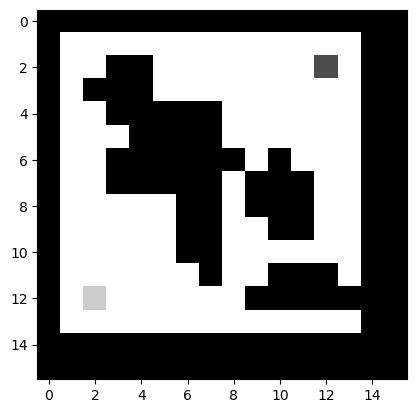

In [4]:
target = (2,12)
starting_pos = (12,2)
env_ = env(pooled_map, pooled_map.shape, 's1', starting_pos, target)
env_.show()

agent_ = agent(starting_pos)